<a href="https://colab.research.google.com/github/arkadjie795/2025-pengolahan-citra-TI-2C/blob/main/jb4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Segmentasi dengan Thresholding Global & Otsu



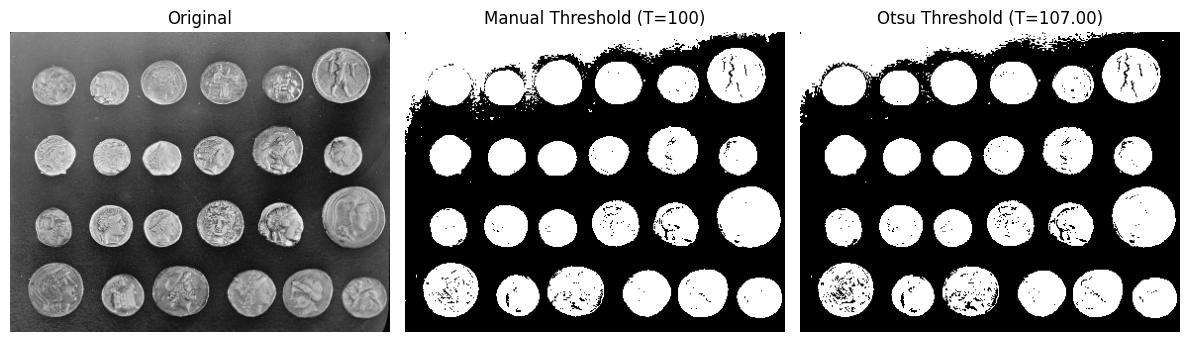

In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters

image_coins = data.coins()

# Manual Thresholding
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_coins, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(binary_manual, cmap='gray')
axes[1].set_title(f'Manual Threshold (T={thresh_manual})')
axes[2].imshow(binary_otsu, cmap='gray')
axes[2].set_title(f'Otsu Threshold (T={thresh_otsu:.2f})')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


#2. Segmentasi dengan Region Growing (Flood Fill)

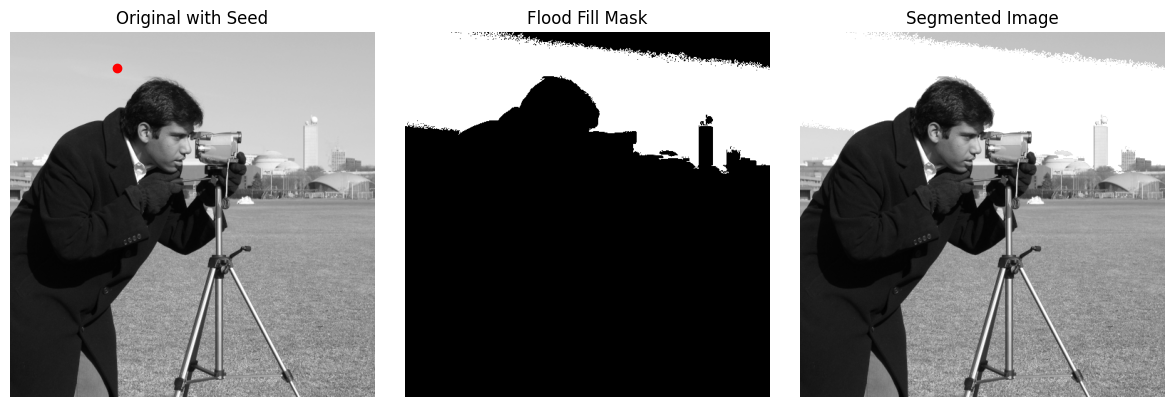

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation

image = data.camera()
seed_point = (50, 150)
flood_mask = segmentation.flood(image, seed_point, tolerance=10)

segmented_image = np.copy(image)
segmented_image[flood_mask] = 255

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray')
axes[0].plot(seed_point[1], seed_point[0], 'ro')
axes[0].set_title('Original with Seed')
axes[1].imshow(flood_mask, cmap='gray')
axes[1].set_title('Flood Fill Mask')
axes[2].imshow(segmented_image, cmap='gray')
axes[2].set_title('Segmented Image')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


#3. Segmentasi Warna dengan K-Means

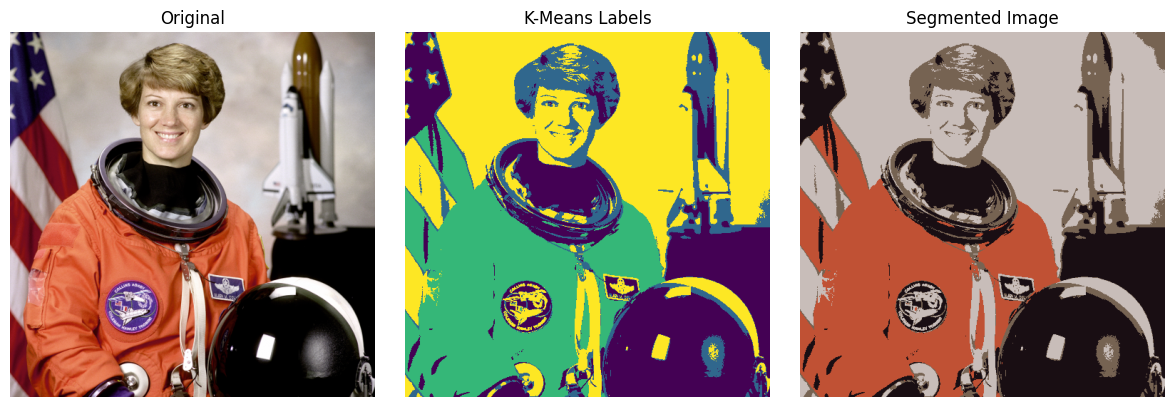

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb

image = data.astronaut().astype(float) / 255.0
image_lab = rgb2lab(image)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixel_features)
segmented = labels.reshape(rows, cols)

segmented_image = np.zeros_like(image_lab)
for k in range(4):
    segmented_image[segmented == k] = kmeans.cluster_centers_[k]

segmented_rgb = lab2rgb(segmented_image)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image); axes[0].set_title("Original")
axes[1].imshow(segmented, cmap='viridis'); axes[1].set_title("K-Means Labels")
axes[2].imshow(segmented_rgb); axes[2].set_title("Segmented Image")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


#4. Segmentasi Watershed

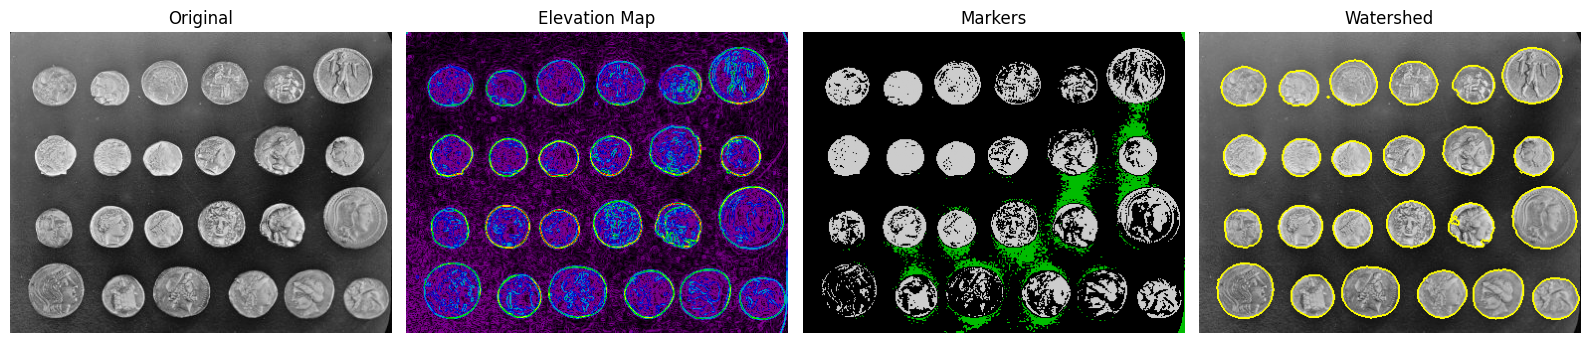

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology

image = data.coins()
elevation = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < 30] = 1
markers[image > 150] = 2

segmentation_result = segmentation.watershed(elevation, markers)
segmented_colored = segmentation.mark_boundaries(image, segmentation_result)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(elevation, cmap='nipy_spectral'); axes[1].set_title("Elevation Map")
axes[2].imshow(markers, cmap='nipy_spectral'); axes[2].set_title("Markers")
axes[3].imshow(segmented_colored); axes[3].set_title("Watershed")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


#5. Perbandingan Semua Metode Segmentasi


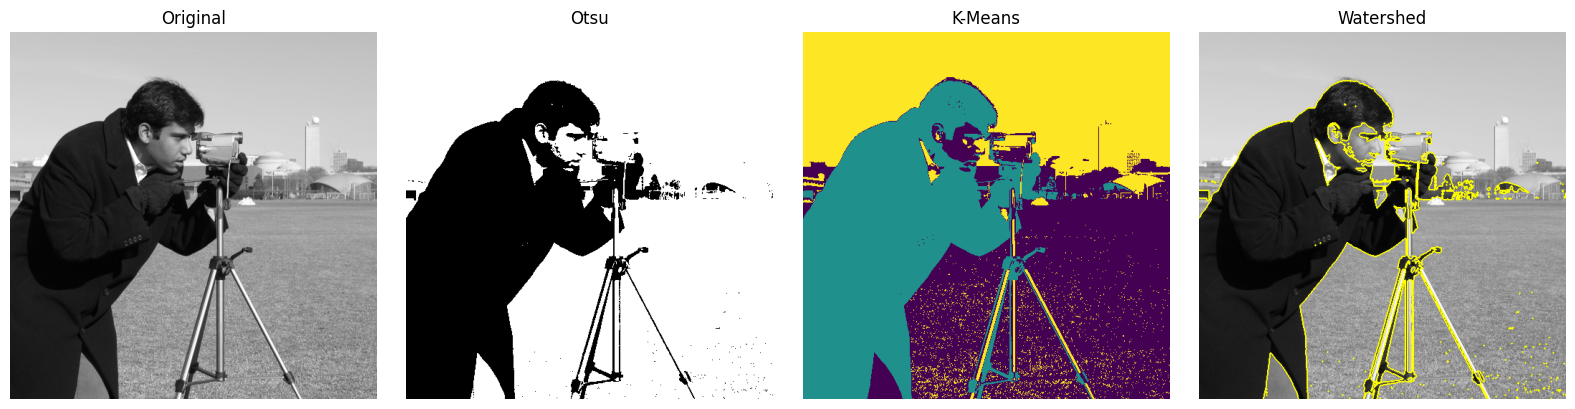

In [5]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float
from sklearn.cluster import KMeans
import numpy as np

image = data.camera()
image_float = img_as_float(image)
thresh = filters.threshold_otsu(image)
binary = image > thresh

pixel_features = image_float.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixel_features).reshape(image.shape)

elevation = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh] = 1
markers[image > thresh] = 2
watershed = segmentation.watershed(elevation, markers)
watershed_colored = segmentation.mark_boundaries(image_float, watershed)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(binary, cmap='gray'); axes[1].set_title("Otsu")
axes[2].imshow(labels, cmap='viridis'); axes[2].set_title("K-Means")
axes[3].imshow(watershed_colored); axes[3].set_title("Watershed")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


##Penugasan (Eksperimen Thresholding)
Thresholding data.page() dengan Otsu, Local, dan Yen

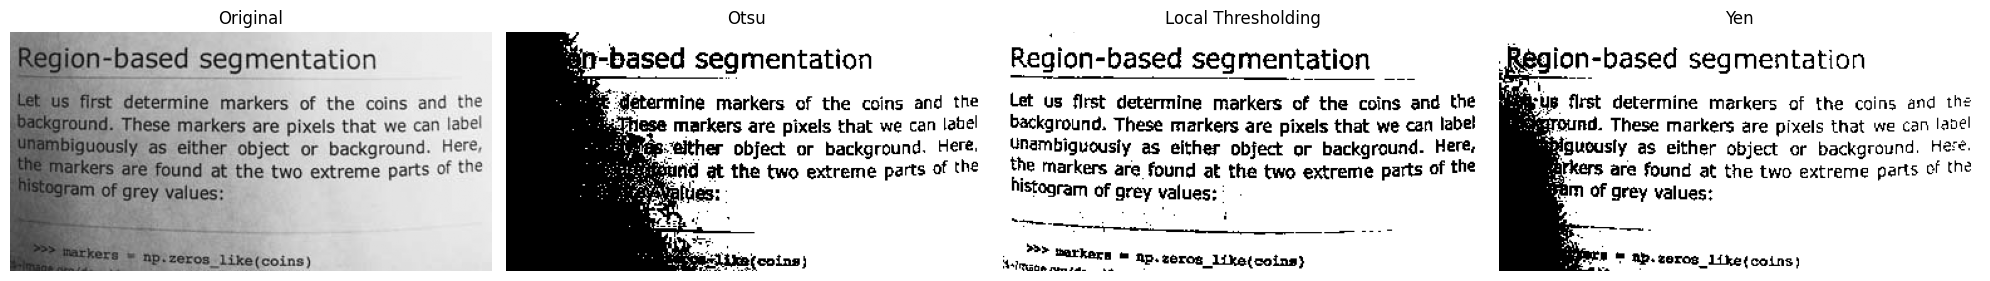

In [7]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.filters import threshold_otsu, threshold_local, threshold_yen
from skimage.util import img_as_ubyte

image = data.page()
image = img_as_ubyte(image)

thresh_otsu = threshold_otsu(image)
binary_otsu = image > thresh_otsu

block_size = 35
local_thresh = threshold_local(image, block_size, offset=10)
binary_local = image > local_thresh

thresh_yen = threshold_yen(image)
binary_yen = image > thresh_yen

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(binary_otsu, cmap='gray'); axes[1].set_title("Otsu")
axes[2].imshow(binary_local, cmap='gray'); axes[2].set_title("Local Thresholding")
axes[3].imshow(binary_yen, cmap='gray'); axes[3].set_title("Yen")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()


##Segmentasi Gambar Sendiri (Mobil Nissan GTR) dengan 3 Metode

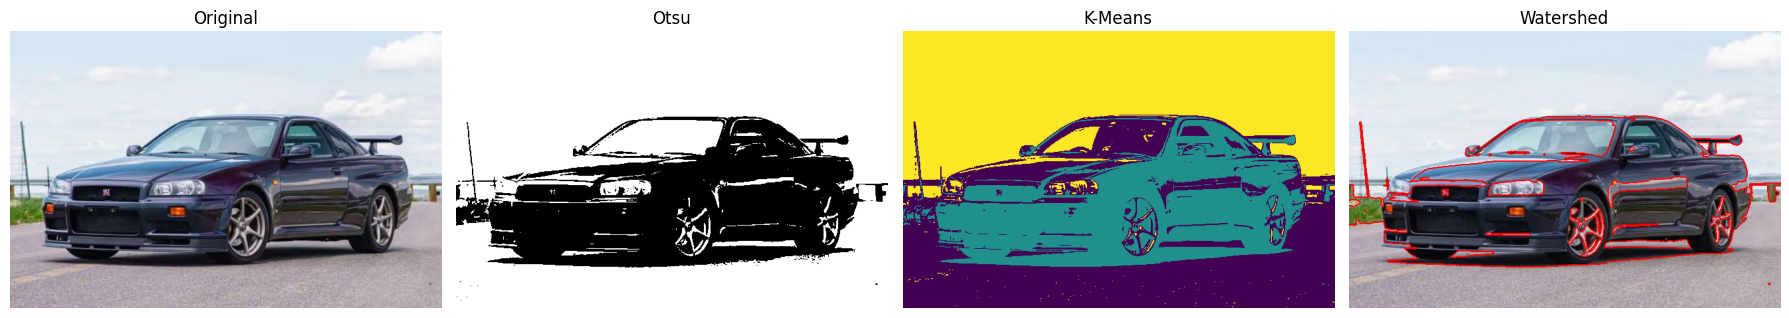

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation
from skimage.color import rgb2gray
from skimage.util import img_as_float
from sklearn.cluster import KMeans
from scipy import ndimage as ndi

# Ganti path sesuai gambar yang kamu pakai
image_path = "Nissan-Skyline-GT-R-V-Spec-Midnight-Purple-II-11.jpg"
image_rgb = io.imread(image_path)
image_gray = rgb2gray(image_rgb)
image_float = img_as_float(image_gray)

# Otsu
thresh = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh

# K-Means
rows, cols = image_gray.shape
pixels = image_float.reshape(rows * cols, 1)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_kmeans = kmeans.fit_predict(pixels).reshape(rows, cols)

# Watershed
elevation = filters.sobel(image_gray)
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[image_gray < 0.3] = 1
markers[image_gray > 0.7] = 2
watershed = segmentation.watershed(elevation, markers)
watershed_colored = segmentation.mark_boundaries(image_rgb, watershed, color=(1, 0, 0))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(image_rgb); axes[0].set_title("Original")
axes[1].imshow(binary_otsu, cmap='gray'); axes[1].set_title("Otsu")
axes[2].imshow(labels_kmeans, cmap='viridis'); axes[2].set_title("K-Means")
axes[3].imshow(watershed_colored); axes[3].set_title("Watershed")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()
